In [2]:
# ============================================================
# SEL 1 — PERSIAPAN LINGKUNGAN DAN PEMERIKSAAN PERANGKAT
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras

# Nilai SEED agar dapat direproduksi
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Semua library berhasil diimport!")
print("TensorFlow versi:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))
print(f"SEED yang digunakan: {SEED}")

Semua library berhasil diimport!
TensorFlow versi: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
SEED yang digunakan: 42


In [3]:
# ============================================================
# SEL 2 — MENYAMBUNGKAN GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Path folder utama proyek
FOLDER_PROYEK = '/content/drive/MyDrive/Skripsi_Kopi'
FOLDER_DATASET = f'{FOLDER_PROYEK}/dataset_kopi'

print("Google Drive tersambung!")
print(f"Folder proyek: {FOLDER_PROYEK}")

# Memeriksa isi folder dataset
print("\nIsi folder dataset_kopi:")
for nama_folder in os.listdir(FOLDER_DATASET):
    print(f" -> {nama_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive tersambung!
Folder proyek: /content/drive/MyDrive/Skripsi_Kopi

Isi folder dataset_kopi:
 -> MENTAH (green) 300 Gambar
 -> SETENGAH MATANG (yellowish) 300 Gambar
 -> MATANG (red) 300 Gambar


In [4]:
# ============================================================
# SEL 3 — KONFIGURASI KELAS DAN VERIFIKASI JUMLAH GAMBAR
# ============================================================

# Nama folder Google Drive
NAMA_FOLDER_ASLI = {
    'green':     'MENTAH (green) 300 Gambar',
    'yellowish': 'SETENGAH MATANG (yellowish) 300 Gambar',
    'red':       'MATANG (red) 300 Gambar'
}

KELAS = ['green', 'yellowish', 'red']
LABEL = {'green': 0, 'yellowish': 1, 'red': 2}
NAMA_KELAS_LENGKAP = ['Mentah (green)', 'Setengah Matang (yellowish)', 'Matang (red)']
IMG_SIZE = 224  # ukuran standar input MobileNetV2

print("Konfigurasi awal:")
print(f"Kelas   : {KELAS}")
print(f"Ukuran  : {IMG_SIZE}x{IMG_SIZE} piksel\n")

# Verifikasi jumlah gambar sebelum dimuat
print("Verifikasi jumlah gambar per kelas:")
total_terhitung = 0
for k in KELAS:
    path_folder = f'{FOLDER_DATASET}/{NAMA_FOLDER_ASLI[k]}'
    jumlah = len(os.listdir(path_folder))
    total_terhitung += jumlah
    print(f"  {k:12s} : {jumlah} gambar")

print(f"\nTotal keseluruhan: {total_terhitung} gambar")

Konfigurasi awal:
Kelas   : ['green', 'yellowish', 'red']
Ukuran  : 224x224 piksel

Verifikasi jumlah gambar per kelas:
  green        : 300 gambar
  yellowish    : 300 gambar
  red          : 300 gambar

Total keseluruhan: 900 gambar


In [5]:
# ============================================================
# SEL 4 — MEMUAT SELURUH CITRA KE ARRAY NUMPY
# ============================================================

images = []
labels = []

for k in KELAS:
    path_folder = f'{FOLDER_DATASET}/{NAMA_FOLDER_ASLI[k]}'
    daftar_file = os.listdir(path_folder)

    for nama_file in daftar_file:
        path_gambar = f'{path_folder}/{nama_file}'

        # 1. Membaca gambar (OpenCV membaca dalam urutan BGR)
        img = cv2.imread(path_gambar)

        # Melewati file yang gagal dibaca (misalnya bukan file gambar)
        if img is None:
            continue

        # 2. Menukar urutan saluran warna dari BGR ke RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Menyeragamkan ukuran menjadi 224x224 piksel
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(LABEL[k])

# Konversi ke array numpy
images = np.array(images)
labels = np.array(labels)

print("Pemuatan citra selesai!")
print(f"Total gambar dimuat : {len(images)}")
print(f"Shape data gambar   : {images.shape}")
print(f"Shape label         : {labels.shape}")

# Verifikasi jumlah per kelas setelah dimuat ke array
print("\nJumlah citra per kelas setelah dimuat:")
for k in KELAS:
    jumlah = np.sum(labels == LABEL[k])
    print(f"  {k:12s} (label {LABEL[k]}) : {jumlah} gambar")

Pemuatan citra selesai!
Total gambar dimuat : 900
Shape data gambar   : (900, 224, 224, 3)
Shape label         : (900,)

Jumlah citra per kelas setelah dimuat:
  green        (label 0) : 300 gambar
  yellowish    (label 1) : 300 gambar
  red          (label 2) : 300 gambar


In [ ]:
# ============================================================
# SEL 5 — PEMBAGIAN DATA DENGAN STRATIFIED SPLIT (70:15:15)
# ============================================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# --- Tahap 1: Memisahkan data uji (15%) dari keseluruhan data ---
X_train_val, X_test, y_train_val, y_test = train_test_split(
    images, labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels
)

# --- Tahap 2: Memisahkan data validasi (15%) dari sisa 85% ---
# test_size=0.176 karena 0.15/0.85 = 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=SEED,
    stratify=y_train_val
)

print("Pembagian dataset berhasil!")
print(f"Data latih   : {X_train.shape[0]} gambar")
print(f"Data validasi: {X_val.shape[0]} gambar")
print(f"Data uji     : {X_test.shape[0]} gambar")
print(f"Total        : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} gambar")

# Verifikasi distribusi kelas pada tiap subset
print("\nDistribusi kelas per subset:")
for k in KELAS:
    n_train = np.sum(y_train == LABEL[k])
    n_val   = np.sum(y_val == LABEL[k])
    n_test  = np.sum(y_test == LABEL[k])
    print(f"  {k:12s} -> latih: {n_train}, validasi: {n_val}, uji: {n_test}")

# --- One-hot encoding label (untuk categorical_crossentropy) ---
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

print("\nOne-hot encoding selesai. Contoh label:")
print(f"Label asli   : {y_train[0]}")
print(f"Label one-hot: {y_train_cat[0]}")

Pembagian dataset berhasil!
Data latih   : 630 gambar
Data validasi: 135 gambar
Data uji     : 135 gambar
Total        : 900 gambar

Distribusi kelas per subset:
  green        -> latih: 210, validasi: 45, uji: 45
  yellowish    -> latih: 210, validasi: 45, uji: 45
  red          -> latih: 210, validasi: 45, uji: 45

One-hot encoding selesai. Contoh label:
Label asli   : 0
Label one-hot: [1. 0. 0.]


In [ ]:
# ============================================================
# SEL 6 — NORMALISASI DATA VALIDASI DAN UJI
# ============================================================
# augmentasi dulu (perlu piksel 0-255), baru normalisasi.

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Normalisasi mengubah rentang piksel dari 0-255 menjadi -1 sampai 1
X_val_processed  = preprocess_input(X_val.astype('float32'))
X_test_processed = preprocess_input(X_test.astype('float32'))

print("Normalisasi data validasi dan uji selesai!")
print(f"Nilai piksel X_val  -> min: {X_val_processed.min():.2f}, max: {X_val_processed.max():.2f}")
print(f"Nilai piksel X_test -> min: {X_test_processed.min():.2f}, max: {X_test_processed.max():.2f}")

# Menyiapkan label aktual
y_true = y_test  # label integer (bukan one-hot), untuk classification_report
print(f"\nJumlah data uji: {len(y_true)} gambar")

Normalisasi data validasi dan uji selesai!
Nilai piksel X_val  -> min: -1.00, max: 1.00
Nilai piksel X_test -> min: -1.00, max: 1.00

Jumlah data uji: 135 gambar


Generator augmentasi data latih berhasil dibuat!
Jumlah batch per epoch: 20


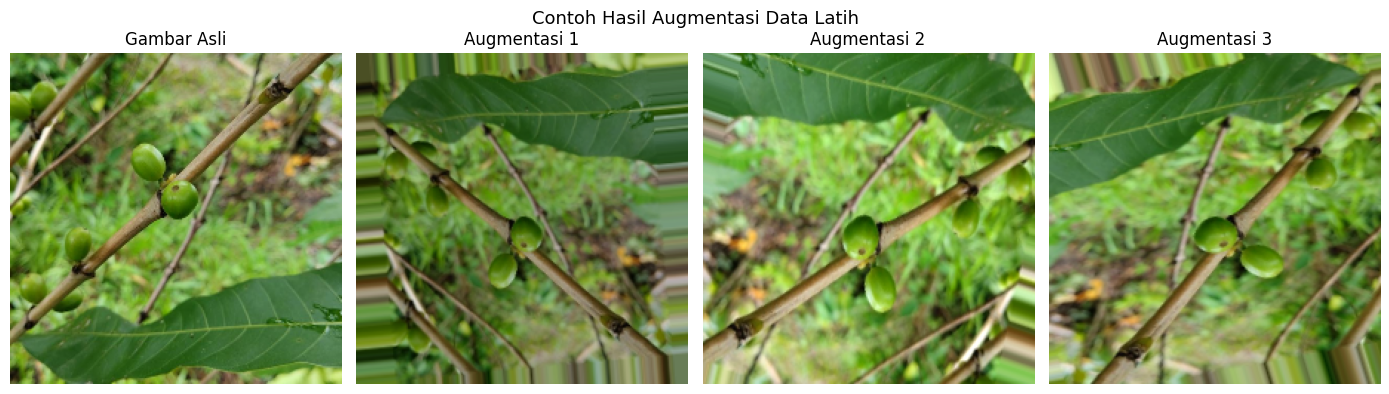

Contoh augmentasi tersimpan di Google Drive!


In [ ]:
# ============================================================
# SEL 7 — AUGMENTASI DATA LATIH
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Definisi generator augmentasi (BAGIAN INI YANG HILANG) ---
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    preprocessing_function=preprocess_input  # normalisasi otomatis setelah augmentasi
)

train_generator = train_datagen.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)

print("Generator augmentasi data latih berhasil dibuat!")
print(f"Jumlah batch per epoch: {len(train_generator)}")

# --- Menampilkan contoh augmentasi (bagian yang sudah diperbaiki) ---
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Contoh Hasil Augmentasi Data Latih', fontsize=13)

contoh_gambar = X_train[0:1]  # 1 gambar sampel (masih 0-255)

axes[0].imshow(contoh_gambar[0].astype('uint8'))
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

generator_contoh = train_datagen.flow(contoh_gambar, batch_size=1, seed=SEED)

for i in range(3):
    batch = next(generator_contoh)
    gambar_tampil = ((batch[0] + 1) * 127.5).astype('uint8')
    axes[i+1].imshow(gambar_tampil)
    axes[i+1].set_title(f'Augmentasi {i+1}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/contoh_augmentasi_baru.png', dpi=150)
plt.show()
print("Contoh augmentasi tersimpan di Google Drive!")

In [ ]:
# ============================================================
# SEL 8 — MEMBANGUN ARSITEKTUR MODEL (MobileNetV2 + Klasifikasi)
# ============================================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers

def bangun_model_mobilenet():
    # Memuat MobileNetV2 dengan bobot ImageNet, tanpa lapisan klasifikasi bawaan
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Membekukan seluruh lapisan MobileNetV2 (tidak ikut dilatih)
    base_model.trainable = False

    # Menambahkan lapisan klasifikasi baru di atasnya
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

# Membangun model untuk Skenario 1
model_s1 = bangun_model_mobilenet()
print("Model Skenario 1 berhasil dibangun!")
model_s1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model Skenario 1 berhasil dibangun!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# SEL 9 — COMPILE DAN LATIH SKENARIO 1 (BASELINE, TANPA AUGMENTASI)
# ============================================================

model_s1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s1_baseline_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Data latih untuk S1 TIDAK diaugmentasi -> normalisasi langsung
X_train_processed = preprocess_input(X_train.astype('float32'))

print("Training Skenario 1 (Baseline)...")
history_s1 = model_s1.fit(
    X_train_processed, y_train_cat,
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_s1,
    verbose=1
)
print("Training Skenario 1 selesai!")

Training Skenario 1 (Baseline)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.4706 - loss: 1.1911
Epoch 1: val_accuracy improved from None to 0.84444, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5984 - loss: 0.8975 - val_accuracy: 0.8444 - val_loss: 0.4374
Epoch 2/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8230 - loss: 0.4192
Epoch 2: val_accuracy improved from 0.84444 to 0.86667, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 124ms/step - accuracy: 0.8365 - loss: 0.4028 - val_accuracy: 0.8667 - val_loss: 0.3799
Epoch 3/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8857 - loss: 0.3039
Epoch 3: val_accuracy did not improve from 0.86667
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8730 - loss: 0.3214 - val_accuracy: 0.8519 - val_loss: 0.3741
Epoch 4/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9137 - loss: 0.2278
Epoch 4: val_accuracy did not improve from 0.86667
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9079 - loss: 0.2510 - val_accuracy: 0.8148 - val_loss: 0.3931
Epoch 5/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9350 - loss: 0.2050
Epoch 5: val_accuracy did not improve from 0.86667
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9333 - loss: 0.2097 - val_accuracy: 0.8444 - val_loss: 0.3840
Epoch 6/50
19/20 ━━━━━━━━━━━━

In [ ]:
# ============================================================
# SEL 10 — MENGEVALUASI SKENARIO 1 PADA DATA UJI
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

y_pred_s1 = model_s1.predict(X_test_processed)
y_pred_s1_kelas = np.argmax(y_pred_s1, axis=1)

print("=== EVALUASI SKENARIO 1 (Baseline) ===\n")
print(classification_report(y_true, y_pred_s1_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
=== EVALUASI SKENARIO 1 (Baseline) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.87      0.89      0.88        45
Setengah Matang (yellowish)       0.79      0.76      0.77        45
               Matang (red)       0.83      0.84      0.84        45

                   accuracy                           0.83       135
                  macro avg       0.83      0.83      0.83       135
               weighted avg       0.83      0.83      0.83       135



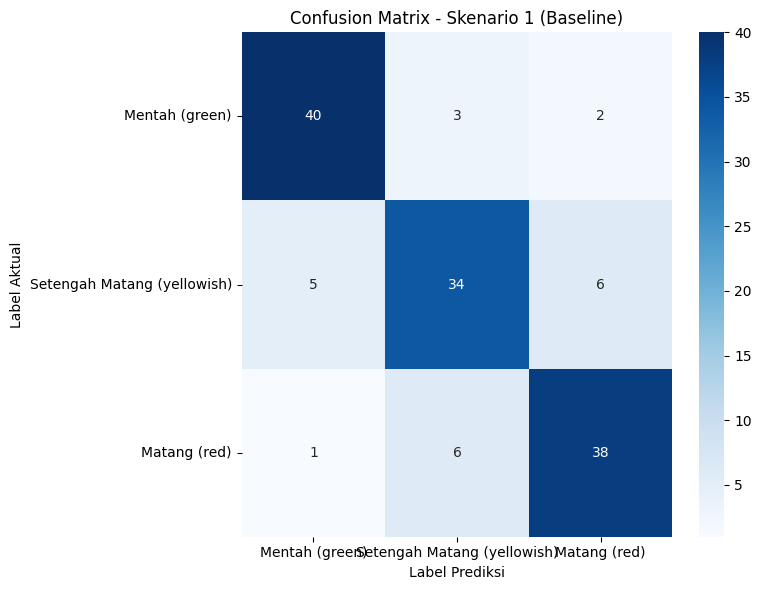

Confusion Matrix Skenario 1:
[[40  3  2]
 [ 5 34  6]
 [ 1  6 38]]

Total per baris: [45 45 45]


In [ ]:
# ============================================================
# SEL 11 — CONFUSION MATRIX SKENARIO 1
# ============================================================

cm_s1 = confusion_matrix(y_true, y_pred_s1_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 1 (Baseline)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario1_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 1:")
print(cm_s1)
print(f"\nTotal per baris: {cm_s1.sum(axis=1)}")

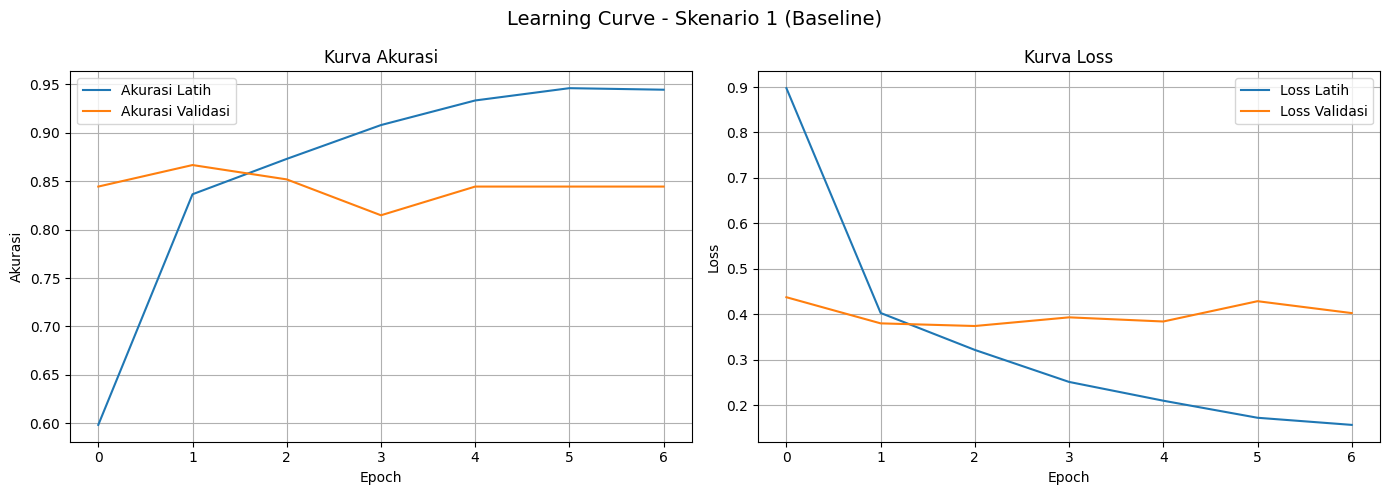

Learning Curve Untuk Skenario 1 tersimpan!


In [ ]:
# ============================================================
# SEL 12 — LEARNING CURVE UNTUK SKENARIO 1
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 1 (Baseline)', fontsize=14)

axes[0].plot(history_s1.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s1.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s1.history['loss'], label='Loss Latih')
axes[1].plot(history_s1.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario1_baru.png', dpi=150)
plt.show()
print("Learning Curve Untuk Skenario 1 tersimpan!")

In [ ]:
# ============================================================
# SEL 13 — MEMBANGUN DAN MELATIH SKENARIO 2 (DENGAN AUGMENTASI)
# ============================================================

# Membangun model BARU (bersih, terpisah dari model_s1)
model_s2 = bangun_model_mobilenet()

model_s2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s2_augmentasi_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 2 (Dengan Augmentasi)...")
history_s2 = model_s2.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 32,
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    callbacks=callbacks_s2,
    verbose=1
)
print("Training Untuk Skenario 2 selesai!")

Training Skenario 2 (Dengan Augmentasi)...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.4763 - loss: 1.0736
Epoch 1: val_accuracy improved from None to 0.82222, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5920 - loss: 0.8886 - val_accuracy: 0.8222 - val_loss: 0.4726
Epoch 2/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6875 - loss: 0.6591

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.82222
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6875 - loss: 0.6591 - val_accuracy: 0.8222 - val_loss: 0.4699
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7702 - loss: 0.5369
Epoch 3: val_accuracy did not improve from 0.82222
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 390ms/step - accuracy: 0.7843 - loss: 0.5098 - val_accuracy: 0.8148 - val_loss: 0.4002
Epoch 4/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.7500 - loss: 0.5086
Epoch 4: val_accuracy did not improve from 0.82222
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7500 - loss: 0.5086 - val_accuracy: 0.8074 - val_loss: 0.4176
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8210 - loss: 0.4331
Epoch 5: val_accuracy did not improve from 0.82222
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 503ms/step - accuracy: 0.8144 - loss: 0.4410 - val_accuracy: 0.8148 - val_loss: 0.3918
Epoch 6/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.7500

In [ ]:
# ============================================================
# SEL 14 — MENGEVALUASI SKENARIO 2 PADA DATA UJI
# ============================================================

y_pred_s2 = model_s2.predict(X_test_processed)
y_pred_s2_kelas = np.argmax(y_pred_s2, axis=1)

print("=== MENGEVALUASI SKENARIO 2 (Dengan Augmentasi) ===\n")
print(classification_report(y_true, y_pred_s2_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
=== MENGEVALUASI SKENARIO 2 (Dengan Augmentasi) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.90      0.84      0.87        45
Setengah Matang (yellowish)       0.68      0.84      0.75        45
               Matang (red)       0.86      0.71      0.78        45

                   accuracy                           0.80       135
                  macro avg       0.82      0.80      0.80       135
               weighted avg       0.82      0.80      0.80       135



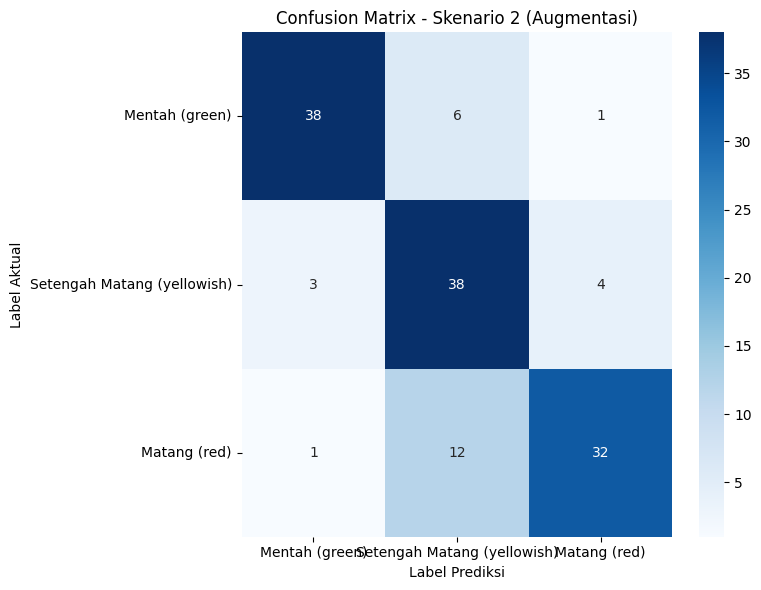

Confusion Matrix Skenario 2:
[[38  6  1]
 [ 3 38  4]
 [ 1 12 32]]

Total per baris: [45 45 45]


In [ ]:
# ============================================================
# SEL 15 — CONFUSION MATRIX SKENARIO 2
# ============================================================

cm_s2 = confusion_matrix(y_true, y_pred_s2_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 2 (Augmentasi)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario2_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 2:")
print(cm_s2)
print(f"\nTotal per baris: {cm_s2.sum(axis=1)}")

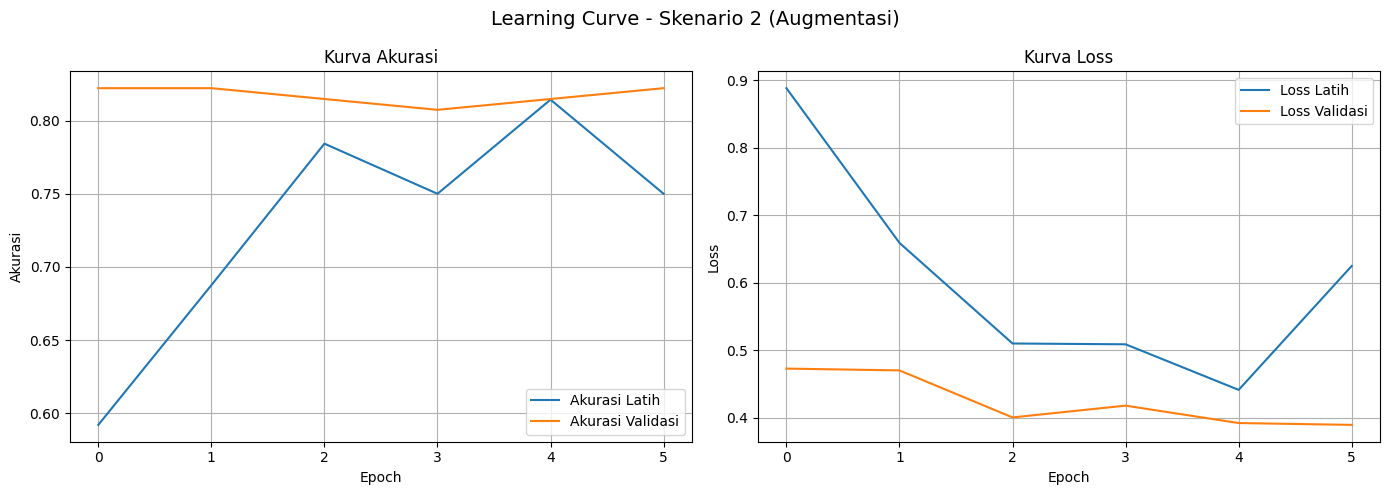

Learning Curve Untuk Skenario 2 tersimpan!


In [ ]:
# ============================================================
# SEL 16 — LEARNING CURVE SKENARIO 2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 2 (Augmentasi)', fontsize=14)

axes[0].plot(history_s2.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s2.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s2.history['loss'], label='Loss Latih')
axes[1].plot(history_s2.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario2_baru.png', dpi=150)
plt.show()
print("Learning Curve Untuk Skenario 2 tersimpan!")

In [ ]:
# ============================================================
# SEL 17 — MEMBUKA 30 LAPISAN TERAKHIR UNTUK FINE-TUNING
# ============================================================
# Skenario 3 melanjutkan dari model_s2 yang SUDAH dilatih,

# Mengambil base model MobileNetV2 dari dalam model_s2
base_model_s3 = model_s2.layers[1]

print(f"Total layer di MobileNetV2: {len(base_model_s3.layers)}")

# Membuka 30 layer terakhir agar ikut dilatih (fine-tuning)
base_model_s3.trainable = True
for layer in base_model_s3.layers[:-30]:
    layer.trainable = False

# Menghitung layer yang dibuka vs dibekukan
jumlah_dibuka = sum(l.trainable for l in base_model_s3.layers)
jumlah_dibekukan = len(base_model_s3.layers) - jumlah_dibuka

print(f"Layer yang dibuka (trainable): {jumlah_dibuka}")
print(f"Layer yang dibekukan: {jumlah_dibekukan}")

Total layer di MobileNetV2: 154
Layer yang dibuka (trainable): 30
Layer yang dibekukan: 124


In [ ]:
# ============================================================
# SEL 18 — COMPILE DAN LATIH SKENARIO 3 (FINE-TUNING)
# ============================================================
# Learning rate diturunkan 10x lipat agar bobot yang sudah
# terbentuk di Skenario 2 tidak rusak

model_s2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model siap untuk fine-tuning! Learning rate: 1e-4")

# Membuat generator BARU
train_generator_s3 = train_datagen.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)

callbacks_s3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s3_finetuning_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 3 (Fine-Tuning)...")
history_s3 = model_s2.fit(
    train_generator_s3,
    steps_per_epoch=len(X_train) // 32,
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    callbacks=callbacks_s3,
    verbose=1
)

# Simpan referensi sebagai model_s3
model_s3 = model_s2
print("Training Pada Skenario 3 selesai!")

Model siap untuk fine-tuning! Learning rate: 1e-4
Training Skenario 3 (Fine-Tuning)...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.7103 - loss: 0.6969
Epoch 1: val_accuracy improved from None to 0.79259, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7274 - loss: 0.6417 - val_accuracy: 0.7926 - val_loss: 0.5251
Epoch 2/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8125 - loss: 0.4578

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.79259
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8125 - loss: 0.4578 - val_accuracy: 0.7926 - val_loss: 0.5274
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7589 - loss: 0.5070
Epoch 3: val_accuracy improved from 0.79259 to 0.80000, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 630ms/step - accuracy: 0.7893 - loss: 0.4600 - val_accuracy: 0.8000 - val_loss: 0.4855
Epoch 4/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8125 - loss: 0.3989
Epoch 4: val_accuracy did not improve from 0.80000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8125 - loss: 0.3989 - val_accuracy: 0.8000 - val_loss: 0.4864
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8782 - loss: 0.3326
Epoch 5: val_accuracy did not improve from 0.80000
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 433ms/step - accuracy: 0.8612 - loss: 0.3616 - val_accuracy: 0.7704 - val_loss: 0.5602
Epoch 6/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 15s 839ms/step - accuracy: 0.7500 - loss: 0.4628
Epoch 6: val_accuracy did not improve from 0.80000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7500 - loss: 0.4628 - val_accuracy: 0.7926 - val_loss: 0.5558
Epoch 7/50
19/19 ━━━━━━


Epoch 7: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 543ms/step - accuracy: 0.8729 - loss: 0.3301 - val_accuracy: 0.8148 - val_loss: 0.4493
Epoch 8/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7812 - loss: 0.4727
Epoch 8: val_accuracy did not improve from 0.81481
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7812 - loss: 0.4727 - val_accuracy: 0.8148 - val_loss: 0.4407
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8904 - loss: 0.2864
Epoch 9: val_accuracy improved from 0.81481 to 0.82963, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.8863 - loss: 0.2918 - val_accuracy: 0.8296 - val_loss: 0.3982
Epoch 10/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8750 - loss: 0.2758
Epoch 10: val_accuracy did not improve from 0.82963
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8750 - loss: 0.2758 - val_accuracy: 0.8296 - val_loss: 0.3995
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9038 - loss: 0.2575
Epoch 11: val_accuracy did not improve from 0.82963
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.8997 - loss: 0.2660 - val_accuracy: 0.8222 - val_loss: 0.4375
Epoch 12/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.9688 - loss: 0.1633
Epoch 12: val_accuracy did not improve from 0.82963
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9688 - loss: 0.1633 - val_accuracy: 0.8296 - val_loss: 0.4302
Epoch 13/50
19/19 


Epoch 13: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 570ms/step - accuracy: 0.9080 - loss: 0.2483 - val_accuracy: 0.8593 - val_loss: 0.3935
Epoch 14/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8750 - loss: 0.2873
Epoch 14: val_accuracy did not improve from 0.85926
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8750 - loss: 0.2873 - val_accuracy: 0.8519 - val_loss: 0.3903
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9233 - loss: 0.2084
Epoch 15: val_accuracy did not improve from 0.85926
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step - accuracy: 0.9197 - loss: 0.2285 - val_accuracy: 0.8222 - val_loss: 0.4284
Epoch 16/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 6s 347ms/step - accuracy: 0.9062 - loss: 0.2198
Epoch 16: val_accuracy did not improve from 0.85926
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9062 - loss: 0.2198 - val_accuracy: 0.8296 - val_loss: 0.4359
Epoch 17/50
19/19

In [ ]:
# ============================================================
# SEL 19 — MENGEVALUASI SKENARIO 3 PADA DATA UJI
# ============================================================

y_pred_s3 = model_s3.predict(X_test_processed)
y_pred_s3_kelas = np.argmax(y_pred_s3, axis=1)

print("=== EVALUASI SKENARIO 3 (Fine-Tuning) ===\n")
print(classification_report(y_true, y_pred_s3_kelas, target_names=NAMA_KELAS_LENGKAP))

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
=== EVALUASI SKENARIO 3 (Fine-Tuning) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.84      0.93      0.88        45
Setengah Matang (yellowish)       0.89      0.69      0.78        45
               Matang (red)       0.84      0.93      0.88        45

                   accuracy                           0.85       135
                  macro avg       0.86      0.85      0.85       135
               weighted avg       0.86      0.85      0.85       135



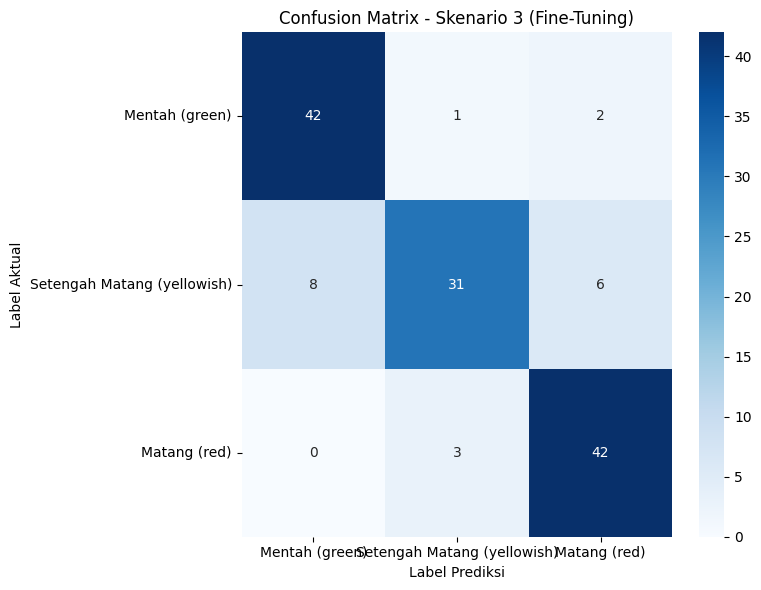

Confusion Matrix Skenario 3:
[[42  1  2]
 [ 8 31  6]
 [ 0  3 42]]

Total per baris: [45 45 45]


In [ ]:
# ============================================================
# SEL 20 — CONFUSION MATRIX SKENARIO 3
# ============================================================

cm_s3 = confusion_matrix(y_true, y_pred_s3_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s3, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 3 (Fine-Tuning)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario3_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 3:")
print(cm_s3)
print(f"\nTotal per baris: {cm_s3.sum(axis=1)}")

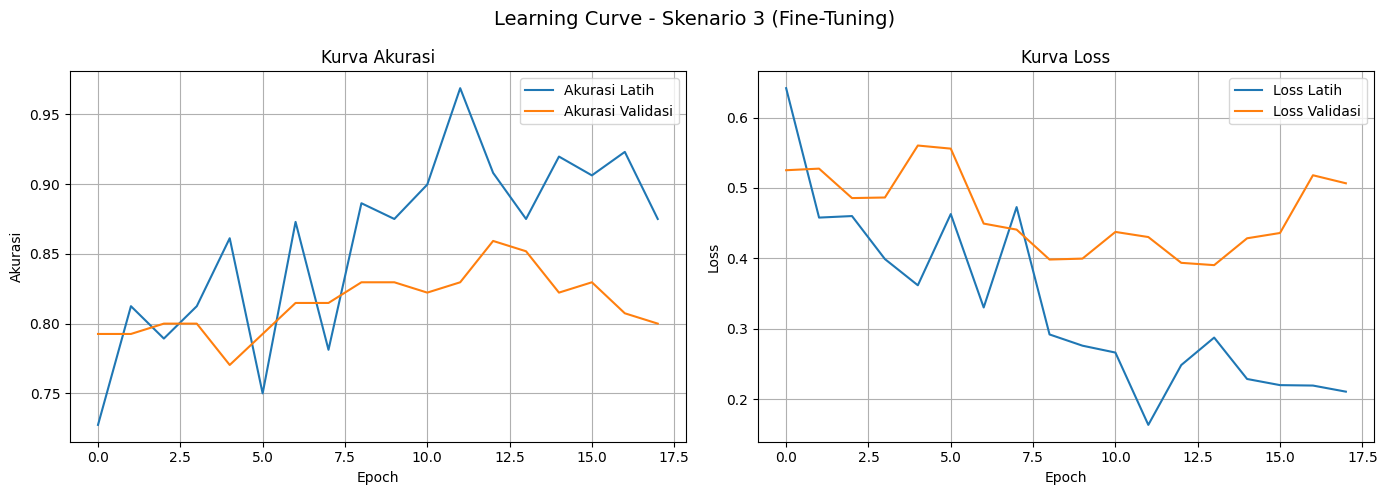

Learning Curve Skenario 3 tersimpan!


In [ ]:
# ============================================================
# SEL 21 — LEARNING CURVE SKENARIO 3
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 3 (Fine-Tuning)', fontsize=14)

axes[0].plot(history_s3.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s3.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s3.history['loss'], label='Loss Latih')
axes[1].plot(history_s3.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario3_baru.png', dpi=150)
plt.show()
print("Learning Curve Skenario 3 tersimpan!")

In [ ]:
# ============================================================
# SEL 22 — MEMBANGUN ARSITEKTUR CNN SEDERHANA DARI NOL
# ============================================================

def bangun_cnn_sederhana():
    model = keras.Sequential([
        # Blok 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),

        # Blok 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Blok 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Klasifikasi
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    return model

tf.random.set_seed(SEED)  # kunci ulang seed sebelum inisialisasi bobot baru
model_s4 = bangun_cnn_sederhana()

print("Model CNN Sederhana (Skenario 4) berhasil dibangun!")
model_s4.summary()

Model CNN Sederhana (Skenario 4) berhasil dibangun!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# SEL 23 — COMPILE DAN LATIH SKENARIO 4 (CNN SEDERHANA)
# ============================================================
# CNN sederhana ini TETAP memakai augmentasi (sama seperti S2/S3)
# tetapi normalisasinya berbeda: rescale 0-1, BUKAN preprocess_input
# MobileNetV2 (karena arsitektur ini tidak dilatih di ImageNet).

train_datagen_s4 = ImageDataGenerator(
    rescale=1./255,              # normalisasi sederhana 0-1
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen_s4 = ImageDataGenerator(rescale=1./255)

train_generator_s4 = train_datagen_s4.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)
val_generator_s4 = val_datagen_s4.flow(
    X_val, y_val_cat,
    batch_size=32,
    shuffle=False
)

model_s4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s4 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s4_cnn_sederhana_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 4 (CNN Sederhana)...")
history_s4 = model_s4.fit(
    train_generator_s4,
    steps_per_epoch=len(X_train) // 32,
    validation_data=val_generator_s4,
    epochs=50,
    callbacks=callbacks_s4,
    verbose=1
)
print("Training Skenario 4 selesai!")

Training Skenario 4 (CNN Sederhana)...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.3623 - loss: 1.0942
Epoch 1: val_accuracy improved from None to 0.50370, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 759ms/step - accuracy: 0.4064 - loss: 1.0836 - val_accuracy: 0.5037 - val_loss: 1.0305
Epoch 2/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4688 - loss: 1.0576

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.50370
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4688 - loss: 1.0576 - val_accuracy: 0.4148 - val_loss: 1.0316
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.4721 - loss: 0.9908
Epoch 3: val_accuracy improved from 0.50370 to 0.52593, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 399ms/step - accuracy: 0.5000 - loss: 0.9678 - val_accuracy: 0.5259 - val_loss: 0.9154
Epoch 4/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.4375 - loss: 1.0126
Epoch 4: val_accuracy improved from 0.52593 to 0.56296, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5000 - loss: 0.8707 - val_accuracy: 0.6519 - val_loss: 0.7137
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5677 - loss: 0.8341
Epoch 9: val_accuracy improved from 0.65185 to 0.67407, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 466ms/step - accuracy: 0.5936 - loss: 0.8123 - val_accuracy: 0.6741 - val_loss: 0.7140
Epoch 10/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.6250 - loss: 0.6697
Epoch 10: val_accuracy did not improve from 0.67407
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.6697 - val_accuracy: 0.6667 - val_loss: 0.7058
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5957 - loss: 0.7963
Epoch 11: val_accuracy improved from 0.67407 to 0.68148, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 11: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 503ms/step - accuracy: 0.6087 - loss: 0.7737 - val_accuracy: 0.6815 - val_loss: 0.6807
Epoch 12/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.6250 - loss: 0.8013
Epoch 12: val_accuracy did not improve from 0.68148
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.8013 - val_accuracy: 0.6815 - val_loss: 0.6823
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6127 - loss: 0.7675
Epoch 13: val_accuracy improved from 0.68148 to 0.68889, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 13: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 437ms/step - accuracy: 0.6221 - loss: 0.7494 - val_accuracy: 0.6889 - val_loss: 0.6555
Epoch 14/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 8s 482ms/step - accuracy: 0.5938 - loss: 0.7642
Epoch 14: val_accuracy did not improve from 0.68889
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5938 - loss: 0.7642 - val_accuracy: 0.6815 - val_loss: 0.6535
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6354 - loss: 0.6952
Epoch 15: val_accuracy did not improve from 0.68889
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.6204 - loss: 0.7272 - val_accuracy: 0.6593 - val_loss: 0.6967
Epoch 16/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.5938 - loss: 0.9624
Epoch 16: val_accuracy did not improve from 0.68889
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5938 - loss: 0.9624 - val_accuracy: 0.6741 - val_loss: 0.6861
Epoch 17/50
19


Epoch 17: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 558ms/step - accuracy: 0.6221 - loss: 0.7396 - val_accuracy: 0.7704 - val_loss: 0.6743
Epoch 18/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.6562 - loss: 0.6614
Epoch 18: val_accuracy did not improve from 0.77037
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6562 - loss: 0.6614 - val_accuracy: 0.7556 - val_loss: 0.6537
Epoch 19/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.6374 - loss: 0.7190
Epoch 19: val_accuracy did not improve from 0.77037
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - accuracy: 0.6555 - loss: 0.6888 - val_accuracy: 0.6741 - val_loss: 0.6584
Epoch 20/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 8s 500ms/step - accuracy: 0.5625 - loss: 0.7296
Epoch 20: val_accuracy did not improve from 0.77037
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5625 - loss: 0.7296 - val_accuracy: 0.6815 - val_loss: 0.6504
Epoch 21/50
19

In [ ]:
# ============================================================
# SEL 24 — EVALUASI SKENARIO 4 PADA DATA UJI
# ============================================================

X_test_s4 = X_test.astype('float32') / 255.0

y_pred_s4 = model_s4.predict(X_test_s4)
y_pred_s4_kelas = np.argmax(y_pred_s4, axis=1)

print("=== EVALUASI SKENARIO 4 (CNN Sederhana) ===\n")
print(classification_report(y_true, y_pred_s4_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
=== EVALUASI SKENARIO 4 (CNN Sederhana) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.86      0.67      0.75        45
Setengah Matang (yellowish)       0.54      0.47      0.50        45
               Matang (red)       0.59      0.80      0.68        45

                   accuracy                           0.64       135
                  macro avg       0.66      0.64      0.64       135
               weighted avg       0.66      0.64      0.64       135



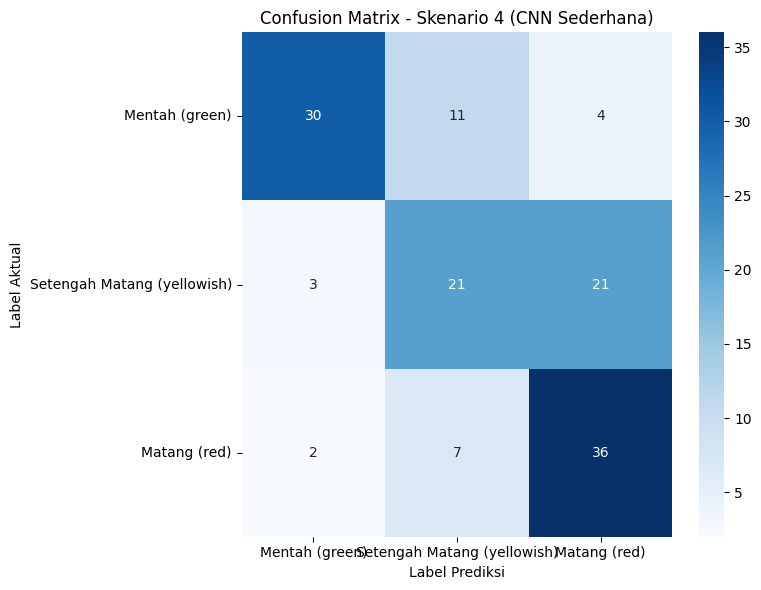

Confusion Matrix Skenario 4:
[[30 11  4]
 [ 3 21 21]
 [ 2  7 36]]

Total per baris: [45 45 45]


In [ ]:
# ============================================================
# SEL 25 — CONFUSION MATRIX SKENARIO 4
# ============================================================

cm_s4 = confusion_matrix(y_true, y_pred_s4_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s4, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 4 (CNN Sederhana)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario4_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 4:")
print(cm_s4)
print(f"\nTotal per baris: {cm_s4.sum(axis=1)}")

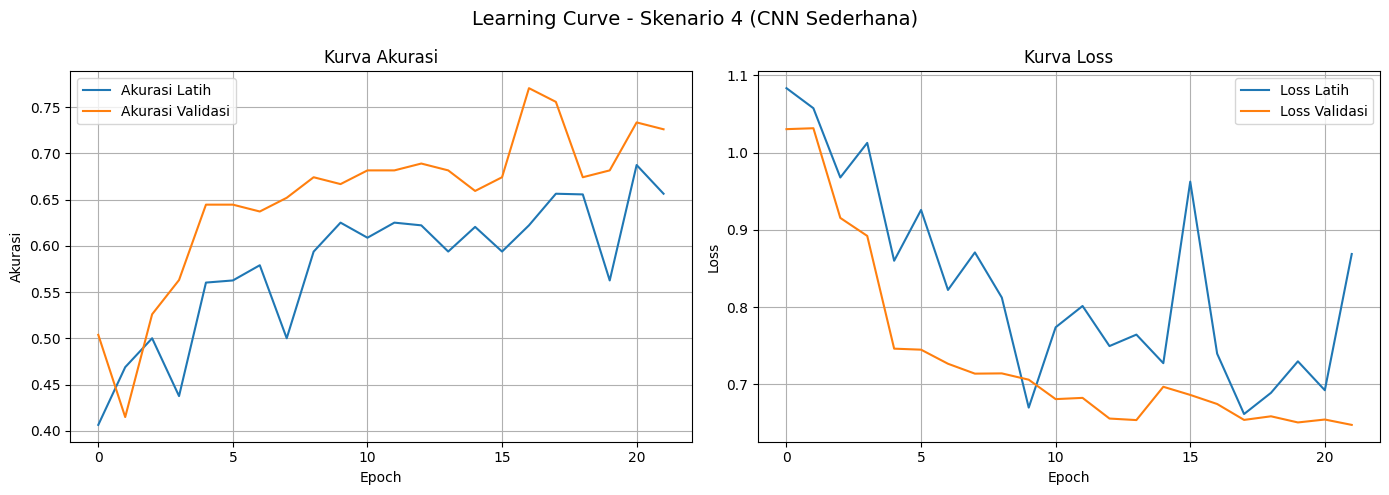

Learning Curve Skenario 4 tersimpan!


In [ ]:
# ============================================================
# SEL 26 — LEARNING CURVE SKENARIO 4
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 4 (CNN Sederhana)', fontsize=14)

axes[0].plot(history_s4.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s4.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s4.history['loss'], label='Loss Latih')
axes[1].plot(history_s4.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario4_baru.png', dpi=150)
plt.show()
print("Learning Curve Skenario 4 tersimpan!")

In [ ]:
# ============================================================
# SEL 27 — TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO
# ============================================================
from sklearn.metrics import f1_score

def hitung_metrik(y_true, y_pred):
    akurasi = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    f1_per_kelas = f1_score(y_true, y_pred, average=None)
    return akurasi, macro_f1, f1_per_kelas

akurasi_s1, macrof1_s1, f1kelas_s1 = hitung_metrik(y_true, y_pred_s1_kelas)
akurasi_s2, macrof1_s2, f1kelas_s2 = hitung_metrik(y_true, y_pred_s2_kelas)
akurasi_s3, macrof1_s3, f1kelas_s3 = hitung_metrik(y_true, y_pred_s3_kelas)
akurasi_s4, macrof1_s4, f1kelas_s4 = hitung_metrik(y_true, y_pred_s4_kelas)

hasil = {
    'Skenario': ['S1 - Baseline', 'S2 - Augmentasi', 'S3 - Fine-Tuning', 'S4 - CNN Sederhana'],
    'Akurasi': [akurasi_s1, akurasi_s2, akurasi_s3, akurasi_s4],
    'Macro F1': [macrof1_s1, macrof1_s2, macrof1_s3, macrof1_s4],
    'F1 Mentah': [f1kelas_s1[0], f1kelas_s2[0], f1kelas_s3[0], f1kelas_s4[0]],
    'F1 Setengah Matang': [f1kelas_s1[1], f1kelas_s2[1], f1kelas_s3[1], f1kelas_s4[1]],
    'F1 Matang': [f1kelas_s1[2], f1kelas_s2[2], f1kelas_s3[2], f1kelas_s4[2]]
}

df_hasil = pd.DataFrame(hasil)
df_hasil_tampil = df_hasil.copy()
for kol in ['Akurasi', 'Macro F1', 'F1 Mentah', 'F1 Setengah Matang', 'F1 Matang']:
    df_hasil_tampil[kol] = df_hasil_tampil[kol].round(2)

print("=" * 70)
print("  TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO")
print("=" * 70)
print(df_hasil_tampil.to_string(index=False))

skenario_terbaik = df_hasil.loc[df_hasil['Akurasi'].idxmax(), 'Skenario']
print(f"\nModel Terbaik: {skenario_terbaik}")

df_hasil.to_csv(f'{FOLDER_PROYEK}/tabel_perbandingan_baru.csv', index=False)
print("Tabel tersimpan di Google Drive!")

  TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO
          Skenario  Akurasi  Macro F1  F1 Mentah  F1 Setengah Matang  F1 Matang
     S1 - Baseline     0.83      0.83       0.88                0.77       0.84
   S2 - Augmentasi     0.80      0.80       0.87                0.75       0.78
  S3 - Fine-Tuning     0.85      0.85       0.88                0.78       0.88
S4 - CNN Sederhana     0.64      0.64       0.75                0.50       0.68

Model Terbaik: S3 - Fine-Tuning
Tabel tersimpan di Google Drive!


In [ ]:
# ============================================================
# SEL 28 — ANALISIS KESALAHAN KLASIFIKASI PADA MODEL TERBAIK
# ============================================================
# Memilih model terbaik SECARA OTOMATIS berdasarkan Sel 27,

peta_prediksi = {
    'S1 - Baseline':      y_pred_s1_kelas,
    'S2 - Augmentasi':    y_pred_s2_kelas,
    'S3 - Fine-Tuning':   y_pred_s3_kelas,
    'S4 - CNN Sederhana': y_pred_s4_kelas
}

y_pred_terbaik = peta_prediksi[skenario_terbaik]

print(f"=== ANALISIS KESALAHAN KLASIFIKASI ({skenario_terbaik}) ===\n")

wrong_idx = np.where(y_pred_terbaik != y_true)[0]
total_data_uji = len(y_true)
jumlah_salah = len(wrong_idx)
jumlah_benar = total_data_uji - jumlah_salah

print(f"Total benar: {jumlah_benar} dari {total_data_uji}")
print(f"Total salah: {jumlah_salah} dari {total_data_uji}\n")

nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']
print("Detail kesalahan klasifikasi (10 pertama):")
print("-" * 55)
for i in wrong_idx[:10]:
    aktual = nama_kelas_simple[y_true[i]]
    prediksi = nama_kelas_simple[y_pred_terbaik[i]]
    print(f"Gambar ke-{i:3d} | Aktual: {aktual:15s} | Prediksi: {prediksi}")

=== ANALISIS KESALAHAN KLASIFIKASI (S3 - Fine-Tuning) ===

Total benar: 115 dari 135
Total salah: 20 dari 135

Detail kesalahan klasifikasi (10 pertama):
-------------------------------------------------------
Gambar ke-  9 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 18 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 29 | Aktual: Mentah          | Prediksi: Matang
Gambar ke- 41 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 47 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 51 | Aktual: Matang          | Prediksi: Setengah Matang
Gambar ke- 52 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 58 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 62 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 88 | Aktual: Matang          | Prediksi: Setengah Matang


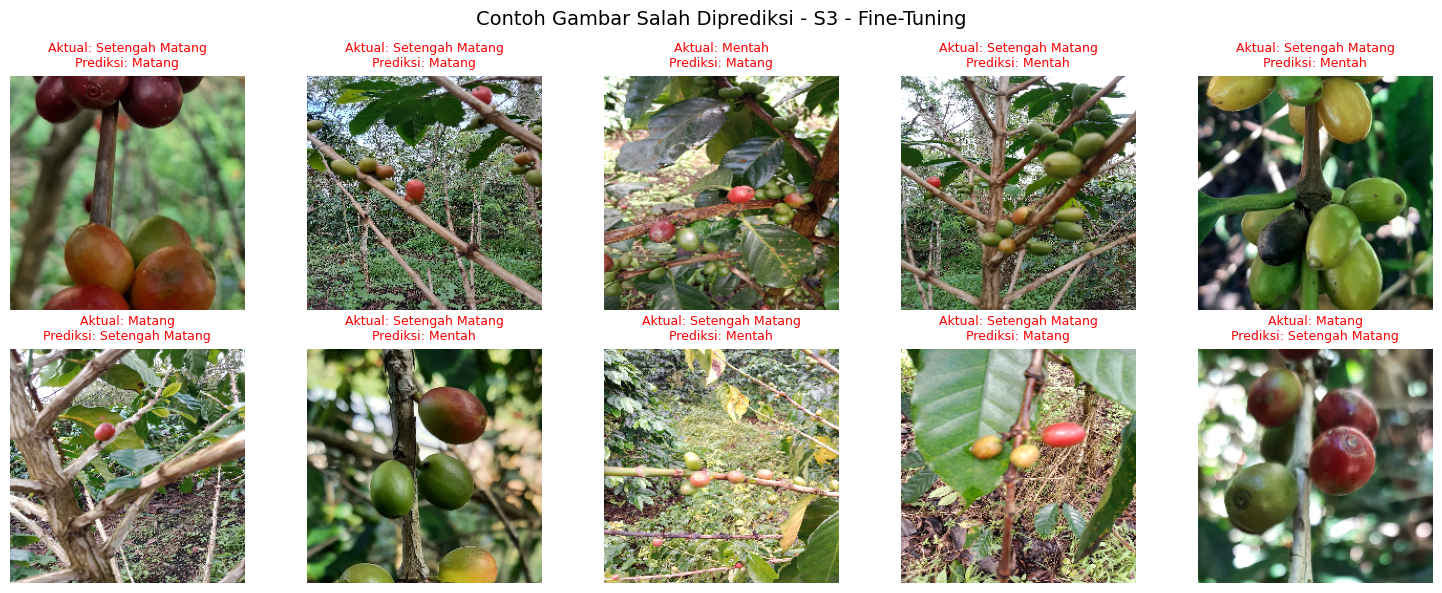

Contoh gambar salah prediksi tersimpan!


In [ ]:
# ============================================================
# SEL 29 — MENAMPILKAN CONTOH CITRA YANG SALAH DIPREDIKSI
# ============================================================

nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Contoh Gambar Salah Diprediksi - {skenario_terbaik}', fontsize=14)
axes = axes.flatten()

for idx, wrong in enumerate(wrong_idx[:10]):
    gambar = X_test[wrong].astype('uint8')  # citra asli 0-255
    aktual = nama_kelas_simple[y_true[wrong]]
    prediksi = nama_kelas_simple[y_pred_terbaik[wrong]]

    axes[idx].imshow(gambar)
    axes[idx].set_title(f'Aktual: {aktual}\nPrediksi: {prediksi}',
                        fontsize=9, color='red')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/gambar_salah_baru.png', dpi=150)
plt.show()
print("Contoh gambar salah prediksi tersimpan!")

In [ ]:
# ============================================================
# SEL 30 (VERSI FINAL) — FUNGSI GRAD-CAM
# ============================================================
# Pendekatan andal untuk model bersarang (MobileNetV2 di dalam model):
# grad_model dibangun HANYA di dalam base MobileNetV2, lalu output
# konvolusinya dilewatkan manual ke lapisan klasifikasi (kepala model).

def buat_gradcam(model, img_preprocessed, kelas_idx):
    base_model = model.layers[1]  # MobileNetV2

    # Ambil lapisan klasifikasi (kepala) yang ada SETELAH MobileNetV2
    # Urutan di model: [Input, MobileNetV2, GAP, Dense, Dropout, Dense]
    kepala_layers = model.layers[2:]  # GAP, Dense, Dropout, Dense

    # grad_model: input MobileNetV2 -> (fitur out_relu, output MobileNetV2)
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer('out_relu').output, base_model.output]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_preprocessed, tf.float32)
        conv_out, base_out = grad_model(inputs)
        tape.watch(conv_out)

        # Lewatkan output MobileNetV2 ke lapisan klasifikasi secara manual
        x = base_out
        for layer in kepala_layers:
            x = layer(x)
        loss = x[:, kelas_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("Fungsi Grad-CAM siap!")

Fungsi Grad-CAM siap!


In [ ]:
# ============================================================
# SEL 31 — VISUALISASI GRAD-CAM PADA 5 CITRA UJI
# ============================================================
# Memakai model_s3 (MobileNetV2). Jika ingin memakai model lain,
# ganti 'model_dipakai' di bawah dengan model_s1 atau model_s2.

model_dipakai = model_s3
nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
fig.suptitle('Visualisasi Grad-CAM - 5 Citra Uji\n(Kiri: Gambar Asli | Kanan: Area Fokus Model)', fontsize=13)

for i in range(5):
    # Gambar asli (0-255)
    img_asli = X_test[i].astype('uint8')

    # Gambar ternormalisasi untuk model (-1 s.d 1)
    img_input = preprocess_input(X_test[i].astype('float32')[np.newaxis, ...])
    kelas_idx = int(y_true[i])

    # Hitung heatmap
    heatmap = buat_gradcam(model_dipakai, img_input, kelas_idx)

    # Proses heatmap jadi overlay warna
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_asli, 0.6, heatmap_color, 0.4, 0)

    aktual = nama_kelas_simple[y_true[i]]
    prediksi = nama_kelas_simple[int(np.argmax(model_dipakai.predict(img_input, verbose=0)))]

    axes[i, 0].imshow(img_asli)
    axes[i, 0].set_title(f'Aktual: {aktual}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f'Prediksi: {prediksi}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/gradcam_5gambar_baru.png', dpi=150)
plt.show()
print("Grad-CAM 5 gambar tersimpan!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# SEL 32 — PENGUKURAN KINERJA KOMPUTASI MODEL TERBAIK
# ============================================================
import time

# Model terbaik dipilih otomatis (sesuai Sel 27)
peta_model = {
    'S1 - Baseline':      (model_s1, X_test_processed),
    'S2 - Augmentasi':    (model_s2, X_test_processed),
    'S3 - Fine-Tuning':   (model_s3, X_test_processed),
    'S4 - CNN Sederhana': (model_s4, X_test_s4)
}
model_terbaik, X_test_untuk_inferensi = peta_model[skenario_terbaik]

print(f"=== EVALUASI KINERJA KOMPUTASI ({skenario_terbaik}) ===\n")

# --- 1. Waktu inferensi rata-rata per gambar ---
_ = model_terbaik.predict(X_test_untuk_inferensi[0:1], verbose=0)

n_samples = 100
total_time = 0
for i in range(n_samples):
    img = X_test_untuk_inferensi[i % len(X_test_untuk_inferensi)][np.newaxis, ...]
    start = time.time()
    model_terbaik.predict(img, verbose=0)
    total_time += (time.time() - start)

avg_ms = (total_time / n_samples) * 1000
print(f"Rata-rata waktu inferensi: {avg_ms:.2f} ms/gambar")

# --- 2. Ukuran berkas model ---
peta_path = {
    'S1 - Baseline':      f'{FOLDER_PROYEK}/model_s1_baseline_baru.h5',
    'S2 - Augmentasi':    f'{FOLDER_PROYEK}/model_s2_augmentasi_baru.h5',
    'S3 - Fine-Tuning':   f'{FOLDER_PROYEK}/model_s3_finetuning_baru.h5',
    'S4 - CNN Sederhana': f'{FOLDER_PROYEK}/model_s4_cnn_sederhana_baru.h5'
}
path_model = peta_path[skenario_terbaik]
size_mb = os.path.getsize(path_model) / (1024 * 1024)
print(f"Ukuran model: {size_mb:.2f} MB")

# --- Ringkasan akhir ---
print("\n=== RINGKASAN AKHIR PENELITIAN ===")
print(f"Model terbaik  : {skenario_terbaik}")
print(f"Akurasi        : {df_hasil.loc[df_hasil['Skenario']==skenario_terbaik, 'Akurasi'].values[0]*100:.0f}%")
print(f"Macro F1       : {df_hasil.loc[df_hasil['Skenario']==skenario_terbaik, 'Macro F1'].values[0]:.2f}")
print(f"Waktu inferensi: {avg_ms:.2f} ms/gambar")
print(f"Ukuran model   : {size_mb:.2f} MB")
print(f"\nModel siap digunakan!")

=== EVALUASI KINERJA KOMPUTASI (S3 - Fine-Tuning) ===

Rata-rata waktu inferensi: 104.77 ms/gambar
Ukuran model: 22.52 MB

=== RINGKASAN AKHIR PENELITIAN ===
Model terbaik  : S3 - Fine-Tuning
Akurasi        : 85%
Macro F1       : 0.85
Waktu inferensi: 104.77 ms/gambar
Ukuran model   : 22.52 MB

Model siap digunakan!


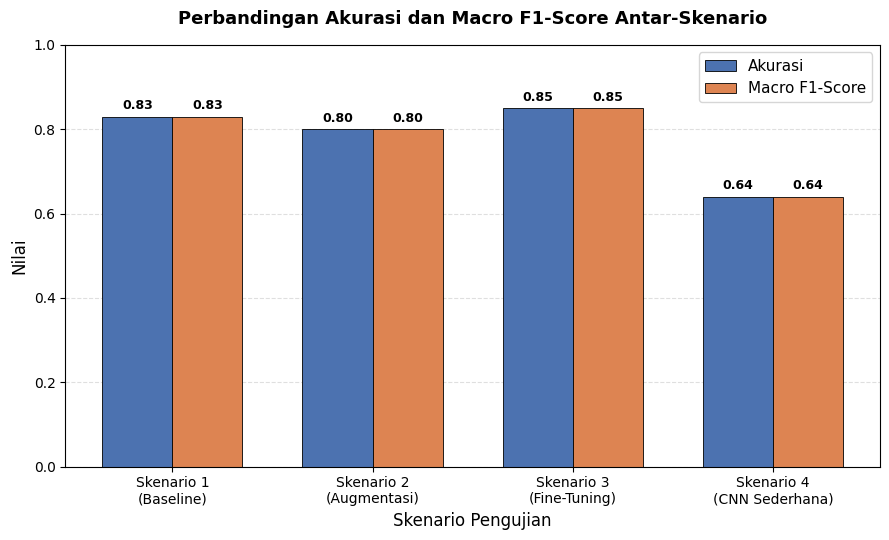

Diagram perbandingan tersimpan di Google Drive!


In [6]:
# ============================================================
# SEL 33 — DIAGRAM BATANG PERBANDINGAN EMPAT SKENARIO
# ============================================================
# Sel ini BERDIRI SENDIRI: angka ditulis langsung, sehingga bisa
# dijalankan tanpa bergantung pada variabel dari sel sebelumnya.
# (Hanya butuh matplotlib, numpy, dan FOLDER_PROYEK)

import matplotlib.pyplot as plt
import numpy as np

# --- Angka hasil final keempat skenario ---
skenario = ['Skenario 1\n(Baseline)',
            'Skenario 2\n(Augmentasi)',
            'Skenario 3\n(Fine-Tuning)',
            'Skenario 4\n(CNN Sederhana)']
akurasi  = [0.83, 0.80, 0.85, 0.64]
macro_f1 = [0.83, 0.80, 0.85, 0.64]

x = np.arange(len(skenario))
lebar = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

batang1 = ax.bar(x - lebar/2, akurasi,  lebar,
                 label='Akurasi', color='#4C72B0',
                 edgecolor='black', linewidth=0.6)
batang2 = ax.bar(x + lebar/2, macro_f1, lebar,
                 label='Macro F1-Score', color='#DD8452',
                 edgecolor='black', linewidth=0.6)

ax.set_ylabel('Nilai', fontsize=12)
ax.set_xlabel('Skenario Pengujian', fontsize=12)
ax.set_title('Perbandingan Akurasi dan Macro F1-Score Antar-Skenario',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(skenario, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Menuliskan nilai di atas tiap batang
def beri_label(batang):
    for b in batang:
        tinggi = b.get_height()
        ax.annotate(f'{tinggi:.2f}',
                    xy=(b.get_x() + b.get_width()/2, tinggi),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

beri_label(batang1)
beri_label(batang2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Skripsi_Kopi/diagram_perbandingan_final.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Diagram perbandingan tersimpan di Google Drive!")